In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import os
import pickle
import pandas as pd
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

from picasso import Picasso, CloneTree
from Bio import Phylo
from io import StringIO

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir



In [ ]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata)

In [3]:
### find which variants can be confidently called as heterozygous vs only mutated (het+homozygous) vs wt (homozygous)

p_allow_heterozygotes = 0.9
p_disallow_heterozygotes = 0.6

variant_df = adata.obsm['genotype_call'].loc[:,(adata.obsm['genotype_call'].notna() & (adata.obsm['genotype_call'] != 'wt')).sum() > 0]
for mutation in variant_df.columns:
    mask_1 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_allow_heterozygotes
    mask_2 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_disallow_heterozygotes
    if (mask_1 == True).sum() > 3000:
        variant_df.loc[~mask_1, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 1})
    elif (mask_2 == True).sum() > 3000:
        variant_df.loc[~mask_2, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 2})
    else:
        variant_df = variant_df.drop(columns=[mutation])

variant_df = variant_df.drop('NRAS c.35G>A', axis=1) ### remove NRAS to help resolution for the dominant 4 variants; then we add NRAS later
data = variant_df.dropna().astype(int)
print(len(data))

730


In [4]:
### run picasso, output is not deterministic so load in the saved output 

filename = '../data/picasso_model.pkl'

if os.path.exists(filename):
    model = pickle.load(open(filename, 'rb'))
else:
    model = Picasso(
        data,
        min_clone_size=40,
        max_depth=6,
        terminate_by='probability'
    )
    # --- Run model ---
    model.fit()
    
# Check if file already exists
if not os.path.exists(filename):
    # Save the trained Picasso model
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print("Model saved as " + filename)


In [5]:
### get phylogeny and add labels by observed mutations in each clone
phylogeny = model.get_phylogeny()
assignments = model.get_clone_assignments()

clone_tree = CloneTree(phylogeny, assignments, data)

labels = {}
for assignment in assignments['clone_id'].unique():
    cells = assignments.loc[assignments['clone_id'] == assignment].index
    df = data.loc[cells].value_counts(normalize=True).reset_index()
    name = ''
    for col in df.columns:
        if col != 'proportion':
            if df.iloc[0][col] == 2:
                name += col.split(' ')[0] + '_'
            elif df.iloc[0][col] == 1:
                name += col.split(' ')[0] + '_het_'
    labels[assignment] = name[:-1]

### sort by length so labels included in other labels are last
labels = dict(sorted(labels.items(), key=lambda x: len(x[0]), reverse=True))

Initialized CloneTree with 5 clones and 730 samples.


Initialized CloneTree with 5 clones and 730 samples.


maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 32 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'H', 'L', 'P', 'R', 'S', 'T', 'Z', 'a', 'b', 'c', 'e', 'five', 'four', 'g', 'h', 'l', 'n', 'nonmarkingreturn', 'one', 'r', 'space', 't', 'three', 'two', 'underscore', 'x', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 36, 38, 40, 43, 47, 51, 53, 54, 55, 61, 66, 68, 69, 70, 72, 74, 75, 79, 81, 85, 87, 91]
Closed glyph list over 'MATH': 32 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'H', 'L', 'P', 'R', 'S', 'T', 'Z', 'a', 'b', 'c', 'e', 'five', 'four', 'g', 'h', 'l', 'n', 'nonmarkingreturn', 'one', 'r', 'space', 't', 'three', 'two', 'underscore', 'x', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 36, 38, 40, 43, 47, 51, 53, 54, 55, 61, 66, 68, 69, 70, 72, 74, 75, 79, 81, 85, 87, 91]
Closing glyph lis

<Figure size 800x600 with 0 Axes>

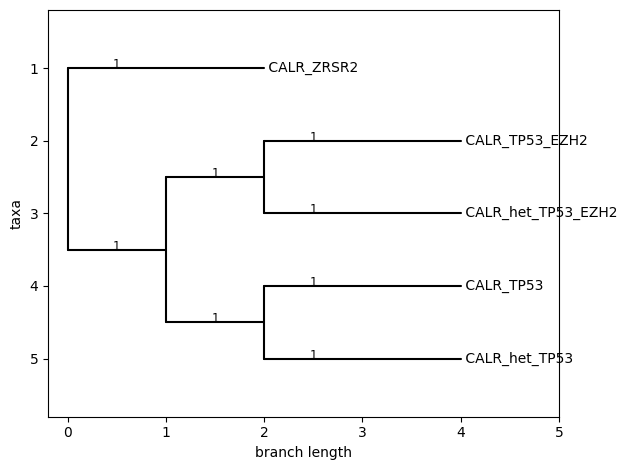

In [6]:
# Create CloneTree with modal aggregation
tree = CloneTree(
    model.get_phylogeny(),
    model.get_clone_assignments(),
    data,
    clone_aggregation='mode'  # Use modal values for clone profiles
)

# Get clone phylogeny as Newick string for external tools 
clone_tree = tree.get_clone_phylogeny()
newick_str = clone_tree.write()

# Replace leaf names safely
renamed_newick = newick_str
for old, new in labels.items():
    # iTOL replace commas or spaces in names with underscores
    safe_name = new.replace(",", "").replace(" ", "_")
    renamed_newick = renamed_newick.replace(old, safe_name)

tree = Phylo.read(StringIO(renamed_newick), "newick")

# graphical plot
fig = plt.figure(figsize=(8,6))
Phylo.draw(tree, do_show=False)   # draws into current axes
plt.tight_layout()
plt.savefig('../plots/picasso_tree.pdf')

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 1.4257822036743164 seconds
Jaccard graph constructed in 8.606475830078125 seconds
Running Leiden optimization
Leiden completed in 10.991218090057373 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 28.150051832199097 seconds


... storing 'cluster_clone' as categorical
... storing 'CALR_clone' as categorical
... storing 'clone' as categorical
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 28 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'H', 'L', 'N', 'P', 'R', 'S', 'T', 'Z', 'c', 'e', 'five', 'h', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'space', 't', 'three', 'two', 'u', 'underscore']
Glyph IDs:   [0, 1, 2, 3, 21, 22, 24, 36, 38, 40, 43, 47, 49, 51, 53, 54, 55, 61, 66, 70, 72, 75, 79, 80, 81, 82, 87, 88]
Closed glyph list over 'MATH': 28 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'H', 'L', 'N', 'P', 'R', 'S', 'T', 'Z', 'c', 'e', 'five', 'h', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'space', 't', 'three', 'two', 'u', 'underscore']
Glyph IDs:   [0, 1, 2, 3, 21, 22, 24, 36, 38, 40, 43, 47, 49, 51, 53, 54, 55, 61, 66, 70, 72, 75, 79, 80, 81,

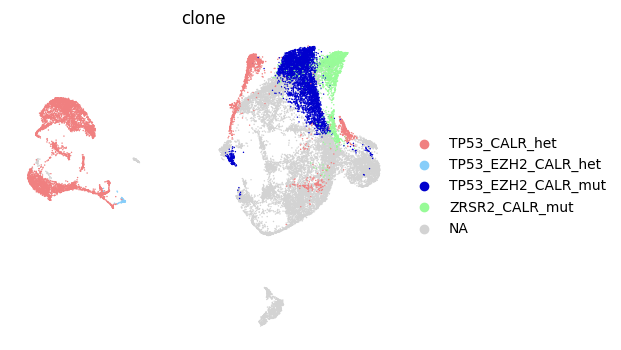

In [7]:
### get higher resolution clustering to assign clusters to clones
sc.external.tl.phenograph(adata, clustering_algo='leiden', k=30, jaccard=True, primary_metric='euclidean', 
                          resolution_parameter=3, seed=1)


## then assign clones
palette = {'ZRSR2_CALR_mut' : 'palegreen',
           'TP53_CALR_het' : 'lightcoral',
           'TP53_CALR_mut' : 'red',
           'TP53_EZH2_CALR_het' : 'lightskyblue',
           'TP53_EZH2_CALR_mut' : 'mediumblue',
           'ambiguous' : 'lightgrey'}

het_threshold = 0.32

clones = {}
clones_CALR = {}

### variant_df: 'mutated': 2, 'wt': 0, 'heterozygous': 2})
### or for CALR: 'mutated': 2, 'wt': 0, 'heterozygous': 1})

for cluster in adata.obs['pheno_leiden'].unique():
    subset = variant_df.loc[adata.obs['pheno_leiden'] == cluster]
    counts_df = subset.apply(pd.Series.value_counts).fillna(0).astype(int)
    counts_df = counts_df / counts_df.sum()
    if counts_df.loc[2,'ZRSR2 c.883C>T'] > het_threshold:
        if (counts_df.loc[2,'TP53 c.818G>A'] > het_threshold) | (counts_df.loc[2,'EZH2 c.2054G>A'] > het_threshold):
            clones[cluster] = 'ambiguous'
        else:
            clones[cluster] = 'ZRSR2'
    elif counts_df.loc[2,'TP53 c.818G>A'] > het_threshold:
        if counts_df.loc[2,'EZH2 c.2054G>A'] > het_threshold:
            clones[cluster] = 'TP53_EZH2'
        else:
            clones[cluster] = 'TP53'
    if counts_df.loc[2, 'CALR c.1150_1154delinsTGTC'] > 0.9:
        clones_CALR[cluster] = 'mut'
    elif counts_df.loc[1, 'CALR c.1150_1154delinsTGTC'] > het_threshold:
        clones_CALR[cluster] = 'het'
    else:
        clones_CALR[cluster] = 'mix'

adata.obs['cluster_clone'] = adata.obs['pheno_leiden'].map(clones)
adata.obs['CALR_clone'] = adata.obs['pheno_leiden'].map(clones_CALR)

adata.obs['clone'] = adata.obs['cluster_clone'] + '_CALR_' + adata.obs['CALR_clone']

adata.obs.loc[~adata.obs['clone'].isin(palette.keys()),'clone'] = None

fig,ax = plt.subplots(figsize=(5,4))
sc.pl.umap(adata, color='clone', palette=palette, frameon=False, ax=ax, show=False, na_color='lightgray')
plt.savefig('../plots/clone_assignment_umap.pdf', dpi=300, bbox_inches='tight')

In [8]:
adata.obs['clone'].to_csv('../output/clone_assignments.csv')